# Paradigm influence on resting-state FC estimates

In [1]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

Loading required package: lpSolve



## Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030). We first load the FC matrices from the generalization protocol, extract the scanner used and keep only the ones scanned on the Prisma. Secondly, we load the FC matrices from the reliability protocol and concatenate the dataframes.

In [2]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths

# Define filtering parameters
metric = "sparseinversecovariance"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-fc")

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration \'hcph\' already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)       
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

## Load files corresponding to the generalization sessions
entities_base_gen = {
    "subject": "001",
    "task": "rest",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}
# Get functional connectivity files
files_gen = layout.get(**entities_base_gen, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_gen) == 36, f"Expected 36 FC matrices, got {len(files_gen)}"
df_fc = pd.DataFrame({"filename": files_gen, "task": "rest", "subject": "001"})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)

# Keep only the session with prisma scanner
df_fc = df_fc[df_fc["scanner"] == "prisma"]
df_fc = df_fc.drop(columns=["scanner"])
assert len(df_fc) == 12, f"Expected 12 FC matrices for prisma scanner, got {len(df_fc)}"

## Load files corresponding to the reliability sessions
entities_base_rel = {
    "subject": "001",
    "task": "rsmovie",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}
# Get functional connectivity files
files_rel = layout.get(**entities_base_rel, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_rel) == 36, f"Expected 36 FC matrices, got {len(files_rel)}"
df_fc_rel = pd.DataFrame({"filename": files_rel, "task": "rsmovie", "subject": "001"})
df_fc_rel["session"] = df_fc_rel["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)
df_fc_rel["repetition"] = df_fc_rel.index + 1

## Concatenate the two dataframes
df_fc = pd.concat([df_fc, df_fc_rel], ignore_index=True)
assert len(df_fc) == 48, f"Expected 48 FC matrices after concatenation, got {len(df_fc)}"
')

In [3]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)
head(df_fc)

,filename,task,subject,session,repetition
,<chr>,<chr>,<chr>,<chr>,<dbl>
1,/data/derivatives/hcph-fc/sub-001/ses-20101060/func/sub-001_ses-20101060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20101060,1
2,/data/derivatives/hcph-fc/sub-001/ses-20201060/func/sub-001_ses-20201060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20201060,2
3,/data/derivatives/hcph-fc/sub-001/ses-20301060/func/sub-001_ses-20301060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20301060,3
4,/data/derivatives/hcph-fc/sub-001/ses-20402060/func/sub-001_ses-20402060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20402060,4
5,/data/derivatives/hcph-fc/sub-001/ses-20502060/func/sub-001_ses-20502060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20502060,5
6,/data/derivatives/hcph-fc/sub-001/ses-20601060/func/sub-001_ses-20601060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,rest,001,20601060,6


## Repeated-measures MANOVA
### Prepare the dataframe for inputting into rm-MANOVA

We add each value from the upper triangle of the functional connectivity (FC) matrix as a separate column in the dataframe. Since the FC matrix is symmetric, retaining only the upper triangle is sufficient. This transformation is necessary because the implementation of repeated-measures MANOVA (rm-MANOVA) requires each variable to be explicitly specified as a column to write the formula determining the dependent and independent variables of the model.

In [4]:
# Load all FC matrices and add them flattened to the dataframe
for (i in seq_len(nrow(df_fc))) {
    tsv_file <- df_fc$filename[i]
    mat <- as.matrix(read.table(tsv_file, header = FALSE, sep = "\t"))
    if (grepl("sparseinversecovariance", tsv_file)) {
        # Negate the precision matrix to get partial correlations
        mat <- -mat
    }
    # Flatten the upper triangle of the matrix (excluding diagonal)
    flat <- mat[upper.tri(mat, diag = FALSE)]
    col_names <- paste0("edge", seq_along(flat))
    # Add values to the dataframe
    for (j in seq_along(flat)) {
        df_fc[i, col_names[j]] <- flat[j]
    }
}
# Remove the filename column as it is no longer needed
df_fc$filename <- NULL

df_fc$task <- as.factor(df_fc$task)
df_fc$repetition <- as.factor(df_fc$repetition)
head(df_fc)

,task,subject,session,repetition,edge1,edge2,edge3,edge4,edge5,edge6,⋯,edge1882,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891
,<fct>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,rest,001,20101060,1,5.713746e-07,6.540584e-07,7.533472e-02,7.260873e-02,-6.969980e-07,-1.520290e-06,⋯,-7.589415e-18,-2.301706e-17,-4.420834e-17,-9.459664e-17,3.980266e-02,-2.027458e-17,2.348138e-17,1.734723e-18,4.349188e-02,5.167582e-17
2,rest,001,20201060,2,3.904534e-07,1.515389e-06,3.453112e-06,-1.415896e-05,-2.232815e-07,-2.602339e-06,⋯,-2.295798e-17,3.557305e-17,1.848350e-17,-3.483355e-17,-6.859457e-17,1.501620e-17,-1.430277e-16,-4.933120e-17,2.647703e-03,-3.850324e-17
3,rest,001,20301060,3,-2.194485e-07,-3.822778e-07,-4.455303e-07,-5.820490e-06,4.210263e-08,1.399272e-07,⋯,2.418090e-17,6.061568e-18,1.372941e-17,-5.814841e-17,3.709595e-17,3.226827e-19,2.556354e-18,2.161465e-17,-1.479906e-17,1.681766e-17
4,rest,001,20402060,4,-7.408846e-07,-6.305500e-07,1.795801e-02,1.182861e-02,-1.366892e-07,-1.521283e-07,⋯,-7.068998e-17,2.278095e-17,6.186826e-18,-3.320535e-17,6.019474e-03,-1.734723e-18,5.124418e-18,1.098414e-02,2.921256e-02,-1.098919e-16
5,rest,001,20502060,5,-1.106089e-06,-3.346216e-07,1.519470e-02,8.503705e-06,-5.014485e-07,-1.172764e-07,⋯,-2.949030e-17,-8.565197e-17,8.787797e-17,-1.837429e-17,1.845945e-01,-1.179612e-16,2.168404e-17,1.228847e-01,3.089862e-02,1.035807e-02
6,rest,001,20601060,6,2.673298e-07,1.783273e-06,5.743289e-06,1.650796e-01,-4.516378e-07,3.283257e-06,⋯,-5.551115e-17,9.220460e-17,6.366088e-17,-7.091021e-17,4.806619e-02,-1.439820e-16,2.896006e-18,7.589415e-17,2.293031e-02,-7.349301e-17


### Construct the formula by concatenating the column names that correspond to edge value

In [5]:
#Construct formula
dep_var <- ''
col_names <- colnames(df_fc)
#Remove non-iqms column names
edge_keys <- col_names[c(-1,-2,-3, -4)]
for (key in edge_keys){
    dep_var <- paste(dep_var, sprintf('%s +',key))
}
dep_var = substring(dep_var,1, nchar(dep_var)-2)

my_formula <- as.formula(paste(dep_var, " ~ task"))
my_formula

edge1 + edge2 + edge3 + edge4 + edge5 + edge6 + edge7 + edge8 + 
    edge9 + edge10 + edge11 + edge12 + edge13 + edge14 + edge15 + 
    edge16 + edge17 + edge18 + edge19 + edge20 + edge21 + edge22 + 
    edge23 + edge24 + edge25 + edge26 + edge27 + edge28 + edge29 + 
    edge30 + edge31 + edge32 + edge33 + edge34 + edge35 + edge36 + 
    edge37 + edge38 + edge39 + edge40 + edge41 + edge42 + edge43 + 
    edge44 + edge45 + edge46 + edge47 + edge48 + edge49 + edge50 + 
    edge51 + edge52 + edge53 + edge54 + edge55 + edge56 + edge57 + 
    edge58 + edge59 + edge60 + edge61 + edge62 + edge63 + edge64 + 
    edge65 + edge66 + edge67 + edge68 + edge69 + edge70 + edge71 + 
    edge72 + edge73 + edge74 + edge75 + edge76 + edge77 + edge78 + 
    edge79 + edge80 + edge81 + edge82 + edge83 + edge84 + edge85 + 
    edge86 + edge87 + edge88 + edge89 + edge90 + edge91 + edge92 + 
    edge93 + edge94 + edge95 + edge96 + edge97 + edge98 + edge99 + 
    edge100 + edge101 + edge102 + edge103 + edge104 

### Run the rm-MANOVA

In [6]:
fit <- multRM(my_formula, data = df_fc, subject = 'subject', within = 'task')
summary(fit)

ERROR: Error in prepare.data(formula, data, subject, within): The number of subjects (1) times the 
  number of within-subject factor levels (2) does not equal
  the total number of observations (48). 
  Check for missing values in the data.


In [ ]:
lhs <- paste0("cbind(", paste(edge_keys, collapse = ","), ")")
rhs <- "task"
formula <- as.formula(paste(lhs, rhs, sep = " ~ "))
print(formula)

manova_model <- manova(formula, data = df_fc)
summary(manova_model)

cbind(edge1, edge2, edge3, edge4, edge5, edge6, edge7, edge8, 
    edge9, edge10, edge11, edge12, edge13, edge14, edge15, edge16, 
    edge17, edge18, edge19, edge20, edge21, edge22, edge23, edge24, 
    edge25, edge26, edge27, edge28, edge29, edge30, edge31, edge32, 
    edge33, edge34, edge35, edge36, edge37, edge38, edge39, edge40, 
    edge41, edge42, edge43, edge44, edge45, edge46, edge47, edge48, 
    edge49, edge50, edge51, edge52, edge53, edge54, edge55, edge56, 
    edge57, edge58, edge59, edge60, edge61, edge62, edge63, edge64, 
    edge65, edge66, edge67, edge68, edge69, edge70, edge71, edge72, 
    edge73, edge74, edge75, edge76, edge77, edge78, edge79, edge80, 
    edge81, edge82, edge83, edge84, edge85, edge86, edge87, edge88, 
    edge89, edge90, edge91, edge92, edge93, edge94, edge95, edge96, 
    edge97, edge98, edge99, edge100, edge101, edge102, edge103, 
    edge104, edge105, edge106, edge107, edge108, edge109, edge110, 
    edge111, edge112, edge113, edge114, edge11

ERROR: Error in summary.manova(manova_model): residuals have rank 46 < 1891


Too many dependent variables, hence we have to run dimensionality reduction before the rm-MANOVA

In [ ]:
pca_result <- prcomp(df_fc[, edge_keys], center = TRUE, scale. = TRUE, retx = TRUE)

In [ ]:
#Extract eigenvalues
diag(cov(pca_result$x))

PC1          PC2          PC3          PC4          PC5          PC6 
4.039101e+02 2.296645e+02 1.531985e+02 6.404893e+01 5.746893e+01 5.271988e+01 
         PC7          PC8          PC9         PC10         PC11         PC12 
4.764475e+01 4.538362e+01 4.384602e+01 4.023142e+01 3.934440e+01 3.590397e+01 
        PC13         PC14         PC15         PC16         PC17         PC18 
3.408589e+01 3.344785e+01 3.183390e+01 3.008845e+01 2.964210e+01 2.868943e+01 
        PC19         PC20         PC21         PC22         PC23         PC24 
2.701514e+01 2.491059e+01 2.402592e+01 2.319963e+01 2.253495e+01 2.224446e+01 
        PC25         PC26         PC27         PC28         PC29         PC30 
2.184795e+01 2.022712e+01 1.944718e+01 1.907732e+01 1.893273e+01 1.872646e+01 
        PC31         PC32         PC33         PC34         PC35         PC36 
1.831559e+01 1.747767e+01 1.684331e+01 1.642813e+01 1.522833e+01 1.491190e+01 
        PC37         PC38         PC39         PC40         PC41         PC42 
1.434153e+01 1.406218e+01 1.364389e+01 1.326081e+01 1.266014e+01 1.215261e+01 
        PC43         PC44         PC45         PC46         PC47         PC48 
1.148182e+01 1.092371e+01 9.774028e+00 8.719745e+00 7.432440e+00 2.871174e-29

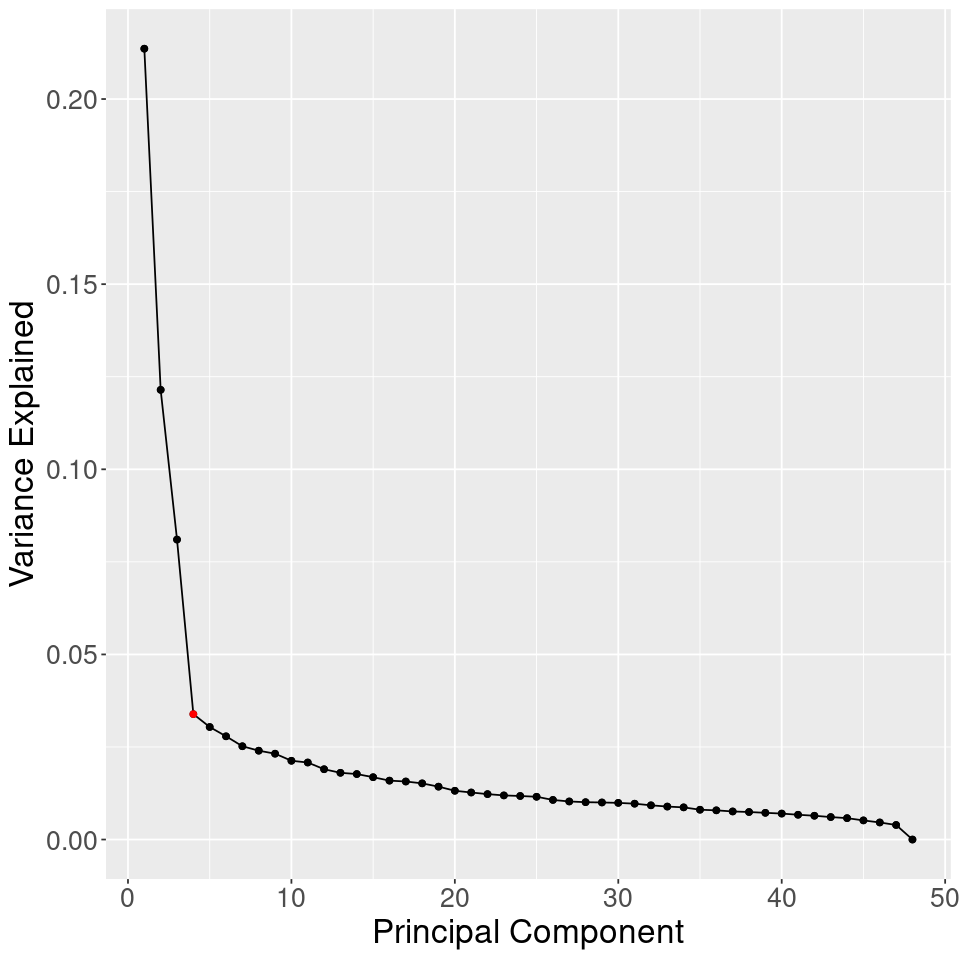

In [ ]:
#Increase plot size
options(repr.plot.width=8, repr.plot.height=8)

#calculate total variance explained by each principal component
var_explained = pca_result$sdev^2 / sum(pca_result$sdev^2)

#create scree plot
library(ggplot2)

# Highlight the number of components selected by the Kaiser criterion
highlight_point <- ifelse(c(1:length(var_explained)) == 4, "#ff0000", "black")

p_pspp <- qplot(c(1:length(var_explained)), var_explained) +  
  geom_line() + 
  geom_point(color = highlight_point) +
  theme(text = element_text(size = 20)) +
  xlab("Principal Component") +
  ylab("Variance Explained") +
  theme(plot.title = element_text(hjust = 1))

print(p_pspp)

In [ ]:
df_pca <- as.data.frame(pca_result$x[, 1:4])
df_pca$task <- df_fc$task

# MANOVA on top PCs
manova_model <- manova(cbind(PC1, PC2, PC3, PC4) ~ task, data = df_pca)
summary(manova_model)

          Df  Pillai approx F num Df den Df    Pr(>F)    
task       1 0.74503   31.412      4     43 2.953e-12 ***
Residuals 46                                             
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## Intra-class correlation coefficient (ICC) to quantify intra-scanner reliability

Let's quantify the intra-scanner reliability of FC estimates when using our naturalistic movie for resting-state.

In [24]:
df_rsmovie <- df_fc[df_fc$task == "rsmovie", ]
df_rsmovie <- t(df_rsmovie[, edge_keys])
head(df_rsmovie)
icc_val <- icc(df_rsmovie, model = "twoway", type = "agreement", unit = "single")$value
cat(sprintf("ICC for rsmovie: %.4f\n", icc_val))

,13,14,15,16,17,18,19,20,21,22,⋯,39,40,41,42,43,44,45,46,47,48
edge1,1.102220e-06,6.415947e-06,-4.595372e-06,3.259803e-06,1.441370e-05,7.021473e-06,-1.020239e-06,5.842345e-05,-7.386642e-07,-1.819866e-06,⋯,1.427782e-07,1.067174e-06,-4.284423e-06,-1.063658e-05,-6.137563e-06,-4.678330e-06,-4.588838e-07,-5.199323e-06,-1.930210e-06,1.125792e-06
edge2,-7.794015e-07,-6.468752e-07,-2.194737e-06,-6.716801e-07,6.054336e-06,2.366883e-06,1.464118e-07,1.635985e-04,3.472887e-06,-1.046269e-07,⋯,-2.036710e-07,9.921960e-08,-3.770929e-06,3.638309e-02,-7.807891e-06,1.433800e-02,-4.062786e-07,1.576103e-02,5.235316e-02,6.780837e-06
edge3,1.139434e-05,5.280384e-06,-8.793063e-06,5.543463e-03,1.137742e-05,5.896386e-02,-1.159955e-06,4.520909e-05,-1.051122e-06,-7.542363e-06,⋯,-2.609990e-06,-2.594676e-06,-5.589937e-06,2.233237e-02,1.421963e-01,-1.567289e-05,-2.738721e-06,9.256322e-06,-1.077018e-05,5.888299e-07
edge4,-2.108473e-05,3.844471e-02,6.452152e-02,3.652434e-02,5.151805e-02,2.030996e-05,4.823714e-02,8.268471e-02,4.989634e-02,5.762318e-02,⋯,4.310278e-02,4.568402e-02,2.367034e-05,-3.039112e-05,-2.870628e-05,7.280732e-06,-5.724659e-06,-2.320633e-06,-1.551173e-06,9.287778e-06
edge5,-5.255465e-07,1.069534e-06,-1.941939e-06,1.990934e-07,6.011015e-06,-1.473689e-07,-4.917529e-07,1.050275e-04,2.452045e-07,-9.815775e-07,⋯,-1.558604e-07,3.366410e-07,-3.251314e-06,3.433093e-06,1.607545e-07,-1.188681e-06,1.352869e-07,1.584268e-08,1.891379e-07,-1.540721e-06
edge6,-6.066261e-06,4.212206e-07,-4.056693e-06,-7.268224e-07,5.638678e-06,1.130457e-06,-5.580014e-08,2.000679e-04,-1.388992e-07,-1.986019e-08,⋯,-2.985605e-07,8.313284e-08,-2.428235e-06,2.739582e-06,-3.661786e-06,6.245403e-06,-4.533894e-08,-4.280846e-07,5.141747e-07,5.194488e-06


ICC for rsmovie: 0.8726


## ICC to quantify variability across paradigms

In [14]:
icc_results <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Randomly select 12 sessions from the rsmovie task because we need to have the same number of sessions for each task to be able to compute ICC
selected_sessions <- sample(unique(df_fc$repetition[df_fc$task == "rsmovie"]), 12)
df_paradigm <- df_fc[df_fc$repetition %in% selected_sessions | df_fc$task == "rest", ]

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_paradigm[, c( "task", edge)]
    df_icc <- pivot_wider(df_icc, names_from = task, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(rest, rsmovie))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_results <- rbind(icc_results, data.frame(edge = edge, ICC = icc_val))
}
df_icc
head(icc_results)


rest,rsmovie
<dbl>,<dbl>
5.167582e-17,8.876246e-17
-3.850324e-17,-3.064470e-16
1.681766e-17,1.789807e-17
-1.098919e-16,2.157146e-02
1.035807e-02,2.153437e-16
-7.349301e-17,1.160874e-16
-3.314509e-17,1.502106e-16
3.888169e-02,2.780553e-02
7.479356e-17,1.006888e-01


,edge,ICC
,<chr>,<dbl>
1,edge1,0.03034207
2,edge2,-0.09073834
3,edge3,-0.13879365
4,edge4,-0.23039911
5,edge5,0.03003050
6,edge6,-0.01445375


Mean ICC across edges: -0.01565024 


Median ICC across edges: -0.0001309638 


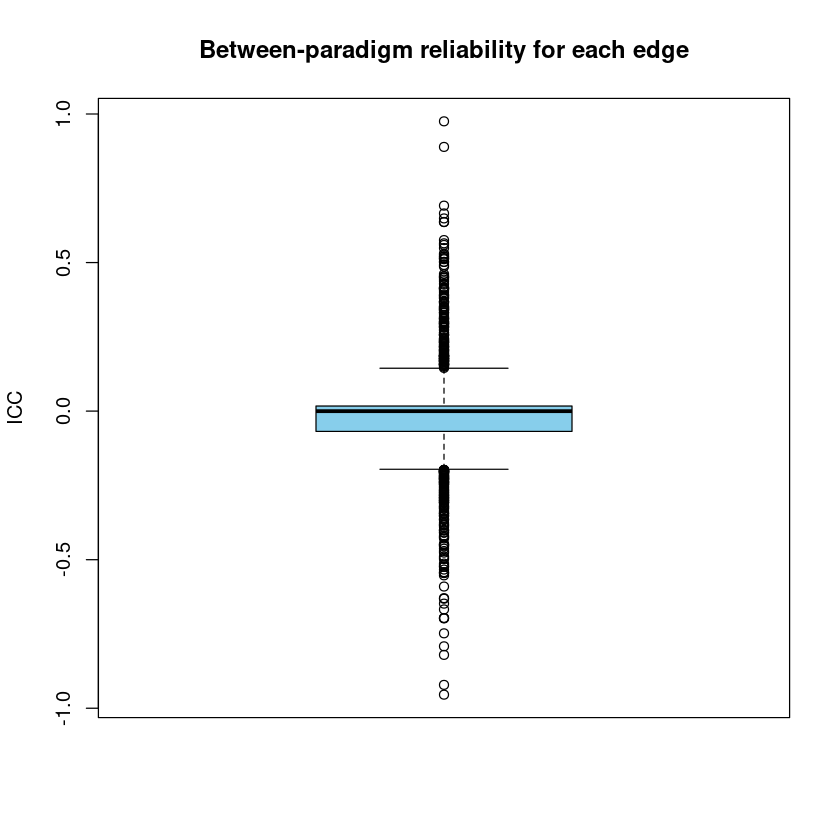

In [18]:
mean_icc <- mean(icc_results$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_results$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_results$ICC, main = "Between-paradigm reliability for each edge", ylab = "ICC", col = "skyblue")

In [43]:
icc_results <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Reset the repetition values for rsmovie sessions to the range 1 to 12 so we can perform the pairing with rest sessions
df_paradigm$repetition[df_paradigm$task == "rsmovie"] <- as.factor(rep(1:12, each = nrow(df_paradigm[df_paradigm$task == "rsmovie", ]) / 12))

for (rep in df_paradigm$repetition) {
    df_rep <- df_paradigm[df_paradigm$repetition == rep, ]
    colnames <- df_rep$task
    df_rep <- t(df_rep[, edge_keys])
    colnames(df_rep) <- colnames
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
    icc_results <- rbind(icc_results, data.frame(edge = edge, ICC = icc_val))
}
head(df_rep)
icc_results

,rest,rsmovie
edge1,-1.738165e-06,1.125792e-06
edge2,-1.091652e-06,6.780837e-06
edge3,1.356319e-05,5.888299e-07
edge4,6.414071e-02,9.287778e-06
edge5,4.221924e-07,-1.540721e-06
edge6,3.592163e-07,5.194488e-06


edge,ICC
<chr>,<dbl>
edge1891,0.6810927
edge1891,0.7384837
edge1891,0.7363833
edge1891,0.8171800
edge1891,0.8152806
edge1891,0.7203766
edge1891,0.8424369
edge1891,0.8339331
edge1891,0.7786184


Mean ICC across edges: 0.7664743 
Quantiles (25%, median, 75%): 0.7150859 0.7585511 0.8213683 


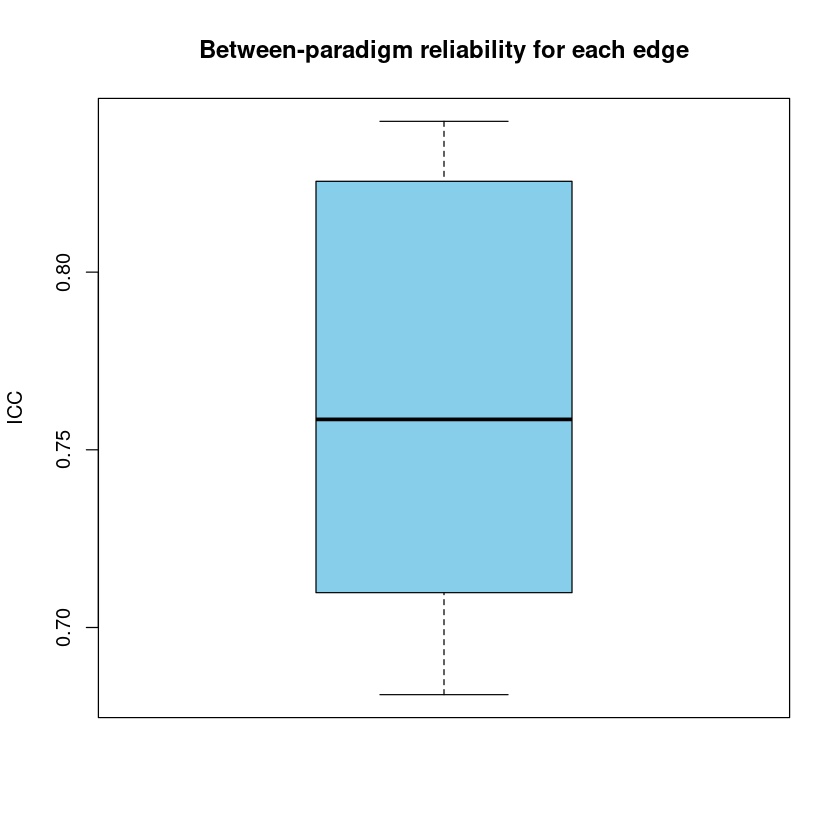

In [45]:
mean_icc <- mean(icc_results$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_results$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

boxplot(icc_results$ICC, main = "Between-paradigm reliability for each edge", ylab = "ICC", col = "skyblue")